# Geodemographic Clustering Case Study

Demonstrates that learned embeddings (100D, 500 Epochs) can be used for geodemographic classification.
Creates 8-cluster classifications from AE and PCA embeddings, evaluates cluster quality.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import joblib
import pickle
from sklearn.decomposition import PCA
import torch
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')


print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available: True


## Configuration

In [2]:
# Parameters
target_dim = 100
n_clusters = 8  # Match OAC supergroups
n_inits = 10000  # Must match 6a
random_seed = 20210321

# Paths
data_path = "../AE_outputs/engcensus_all/"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
geo_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
oac_path = "../data/OAC/OAC_assignment.csv"

# Stability checkpoint path (for median run embeddings and model)
stability_path = f"../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_{target_dim}d.pkl"

# Output directories
plots_dir = "./plots/clustering_plots/"
results_dir = "./clustering_results/"
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print(f"Creating {n_clusters} clusters from {target_dim}D embeddings (500 EPOCH MEDIAN RUN)")
print(f"Random seed: {random_seed}")
print(f"n_inits: {n_inits}")

Creating 8 clusters from 100D embeddings (500 EPOCH MEDIAN RUN)
Random seed: 20210321
n_inits: 10000


## Load Data

In [3]:
# Load original census data
print("Loading census data...")
df_census = pd.read_parquet(cleaned_data_path)
df_census = df_census.set_index('OA')
print(f"Census data: {df_census.shape}")

# Load PCA embeddings (compute on the fly - deterministic)
print(f"\nComputing PCA {target_dim}D embeddings...")
pca = PCA(n_components=target_dim, random_state=random_seed)
pca_embeddings = pca.fit_transform(df_census)
pca_latent_df = pd.DataFrame(pca_embeddings, index=df_census.index)
print(f"PCA embeddings: {pca_latent_df.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Load AE embeddings from stability checkpoint (500 EPOCH MEDIAN RUN)
print(f"\nLoading stability checkpoint from: {stability_path}")
with open(stability_path, 'rb') as f:
    checkpoint = pickle.load(f)

embeddings_list = checkpoint['embeddings_list']
reco_errors_list = checkpoint['reco_errors_list']
n_runs = checkpoint['n_runs']
print(f"Loaded {n_runs} runs from stability checkpoint")

# Find the median run (by overall RMSE)
rmse_per_run = []
for run_idx, reco_err in enumerate(reco_errors_list):
    rmse = np.sqrt(reco_err.mean()) * 100
    rmse_per_run.append(rmse)

rmse_per_run = np.array(rmse_per_run)
median_rmse = np.median(rmse_per_run)
median_run_idx = np.argmin(np.abs(rmse_per_run - median_rmse))

print(f"\nMedian RMSE: {median_rmse:.4f}%")
print(f"Median run index: {median_run_idx} (RMSE = {rmse_per_run[median_run_idx]:.4f}%)")

# Get median run embeddings
ae_embeddings = embeddings_list[median_run_idx]
ae_latent_df = pd.DataFrame(ae_embeddings, index=df_census.index)
print(f"\nAE embeddings (median run): {ae_latent_df.shape}")

# Load OAC
print(f"\nLoading OAC classifications...")
oac = pd.read_csv(oac_path)
oac = oac[['Geography_Code', 'Supergroup8']].rename(columns={'Geography_Code': 'OA'})
oac = oac.set_index('OA')
oac = oac.reindex(df_census.index)
print(f"OAC: {oac.shape}")
print(f"OAC Supergroups: {oac['Supergroup8'].nunique()} unique groups")

Loading census data...
Census data: (188880, 408)

Computing PCA 100D embeddings...
PCA embeddings: (188880, 100)
Explained variance: 0.984

Loading stability checkpoint from: ../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_100d.pkl
Loaded 10 runs from stability checkpoint

Median RMSE: 0.7931%
Median run index: 5 (RMSE = 0.7925%)

AE embeddings (median run): (188880, 100)

Loading OAC classifications...
OAC: (188880, 1)
OAC Supergroups: 8 unique groups


## Cluster Center Decoding Analysis

**Goal**: Test if averaging in latent space produces meaningful cluster prototypes.

**Method**:
1. Compute cluster centers in latent space (mean of embeddings per cluster)
2. Decode these centers back to 408D:
   - PCA: Use inverse_transform()
   - AE: Pass through decoder network
3. Compare decoded centers vs actual means of original data for each cluster

**Expected Result**:
- PCA should match perfectly (linearity)
- AE may have small discrepancies (non-linearity)
- Small discrepancies → latent space preserves cluster structure well

### Import Autoencoder Architecture

In [4]:
# Import the AutoEncoder class from torchgeodemo package
from torchgeodemo.models import AutoEncoder

print(f"✓ Imported AutoEncoder from torchgeodemo.models")
print(f"  This is the same architecture used to train the models")

✓ Imported AutoEncoder from torchgeodemo.models
  This is the same architecture used to train the models


### Load Trained Autoencoder Model

In [5]:
# Load trained AE model from saved weights (500 EPOCH MEDIAN RUN)
input_dim = df_census.shape[1]  # 408 variables
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Loading model for run {median_run_idx}...")

# Load saved model for the median run
models_dir = "../AE_outputs/retraining_stability_500epochs_linscaling/models/"
model_file = f"{models_dir}/stability_{target_dim}d_run_{median_run_idx}__ae_{target_dim}d_{target_dim}d_run_{median_run_idx}_500ep_v1__model.pth"
print(f"Loading from: {model_file}")

ae_model = torch.load(model_file, map_location=device, weights_only=False)
ae_model = ae_model.to(device)
ae_model.eval()

print(f"Loaded AE model (run {median_run_idx})")
print(f"  Model type: {type(ae_model).__name__}")
print(f"  Device: {device}")

Loading model for run 5...
Loading from: ../AE_outputs/retraining_stability_500epochs_linscaling/models//stability_100d_run_5__ae_100d_100d_run_5_500ep_v1__model.pth
Loaded AE model (run 5)
  Model type: AutoEncoder
  Device: cuda


In [6]:
# Load the kmeans clustering results for AE and PCA embeddings
clustering_file = f"{results_dir}/cluster_assignments_{target_dim}d_k{n_clusters}_n{n_inits}.csv"
pca_model_file = f"{results_dir}/kmeans_pca_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"
ae_model_file = f"{results_dir}/kmeans_ae_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"

print(f"Loading clustering results from {clustering_file}...")
clusters_df = pd.read_csv(clustering_file, index_col=0)
kmeans_pca = joblib.load(pca_model_file)
kmeans_ae = joblib.load(ae_model_file)

pca_clusters = clusters_df['pca_cluster'].values
ae_clusters = clusters_df['ae_cluster'].values

print(f"Loaded {len(clusters_df)} cluster assignments")
print(f"KMeans models loaded from {pca_model_file} and {ae_model_file}")

Loading clustering results from ./clustering_results//cluster_assignments_100d_k8_n10000.csv...
Loaded 188880 cluster assignments
KMeans models loaded from ./clustering_results//kmeans_pca_100d_k8_n10000.joblib and ./clustering_results//kmeans_ae_100d_k8_n10000.joblib


### Compute Cluster Centers in Latent Space

In [7]:
print("Computing cluster centers in latent space...\n")

# Get cluster centers from KMeans (already computed during clustering)
pca_cluster_centers = kmeans_pca.cluster_centers_  # shape: (n_clusters, target_dim)
ae_cluster_centers = kmeans_ae.cluster_centers_    # shape: (n_clusters, target_dim)

print(f"PCA cluster centers: {pca_cluster_centers.shape}")
print(f"AE cluster centers: {ae_cluster_centers.shape}")

# Also compute actual means in original space for each cluster
pca_actual_means = np.zeros((n_clusters, input_dim))
ae_actual_means = np.zeros((n_clusters, input_dim))

for cluster_id in range(n_clusters):
    # PCA cluster actual mean
    pca_mask = pca_clusters == cluster_id
    pca_actual_means[cluster_id] = df_census[pca_mask].mean().values
    
    # AE cluster actual mean
    ae_mask = ae_clusters == cluster_id
    ae_actual_means[cluster_id] = df_census[ae_mask].mean().values

print(f"\nPCA actual means: {pca_actual_means.shape}")
print(f"AE actual means: {ae_actual_means.shape}")

Computing cluster centers in latent space...

PCA cluster centers: (8, 100)
AE cluster centers: (8, 100)

PCA actual means: (8, 408)
AE actual means: (8, 408)


### Decode Cluster Centers Back to Original Space

In [8]:
print("Decoding cluster centers back to 408D...\n")

# PCA: Use inverse_transform
print("PCA inverse transform...")
pca_decoded_centers = pca.inverse_transform(pca_cluster_centers)
print(f"  PCA decoded centers: {pca_decoded_centers.shape}")

# AE: Pass through decoder
print("\nAE decoder...")
with torch.no_grad():
    ae_centers_tensor = torch.FloatTensor(ae_cluster_centers).to(device)
    ae_decoded_centers = ae_model.decoder(ae_centers_tensor).cpu().numpy()
print(f"  AE decoded centers: {ae_decoded_centers.shape}")

print(f"\n✓ Decoded {n_clusters} cluster centers for both methods")

Decoding cluster centers back to 408D...

PCA inverse transform...
  PCA decoded centers: (8, 408)

AE decoder...
  AE decoded centers: (8, 408)

✓ Decoded 8 cluster centers for both methods


### Compute Discrepancy Metrics

In [9]:
print("="*80)
print("CLUSTER CENTER DECODING METRICS")
print("="*80)

# Compute metrics for each cluster
pca_metrics = []
ae_metrics = []

for cluster_id in range(n_clusters):
    # PCA metrics
    pca_decoded = pca_decoded_centers[cluster_id]
    pca_actual = pca_actual_means[cluster_id]
    pca_rmse = np.sqrt(np.mean((pca_decoded - pca_actual)**2))
    pca_corr, _ = pearsonr(pca_decoded, pca_actual)
    pca_metrics.append({'cluster': cluster_id, 'rmse': pca_rmse, 'correlation': pca_corr})
    
    # AE metrics
    ae_decoded = ae_decoded_centers[cluster_id]
    ae_actual = ae_actual_means[cluster_id]
    ae_rmse = np.sqrt(np.mean((ae_decoded - ae_actual)**2))
    ae_corr, _ = pearsonr(ae_decoded, ae_actual)
    ae_metrics.append({'cluster': cluster_id, 'rmse': ae_rmse, 'correlation': ae_corr})

# Convert to DataFrames
pca_metrics_df = pd.DataFrame(pca_metrics)
ae_metrics_df = pd.DataFrame(ae_metrics)

# Overall metrics
pca_mean_rmse = pca_metrics_df['rmse'].mean()
ae_mean_rmse = ae_metrics_df['rmse'].mean()
pca_mean_corr = pca_metrics_df['correlation'].mean()
ae_mean_corr = ae_metrics_df['correlation'].mean()

print(f"\nPCA (decoded center vs actual mean):")
print(f"  Mean RMSE: {pca_mean_rmse:.6f}")
print(f"  Mean Correlation: {pca_mean_corr:.6f}")
print(f"  RMSE range: [{pca_metrics_df['rmse'].min():.6f}, {pca_metrics_df['rmse'].max():.6f}]")
print(f"  Corr range: [{pca_metrics_df['correlation'].min():.6f}, {pca_metrics_df['correlation'].max():.6f}]")

print(f"\nAE (decoded center vs actual mean):")
print(f"  Mean RMSE: {ae_mean_rmse:.6f}")
print(f"  Mean Correlation: {ae_mean_corr:.6f}")
print(f"  RMSE range: [{ae_metrics_df['rmse'].min():.6f}, {ae_metrics_df['rmse'].max():.6f}]")
print(f"  Corr range: [{ae_metrics_df['correlation'].min():.6f}, {ae_metrics_df['correlation'].max():.6f}]")

print(f"\nComparison:")
print(f"  RMSE ratio (AE/PCA): {ae_mean_rmse / pca_mean_rmse:.2f}x")
print(f"  Correlation difference (AE - PCA): {ae_mean_corr - pca_mean_corr:+.6f}")

# Per-cluster breakdown
print(f"\n{'='*80}")
print("PER-CLUSTER METRICS")
print(f"{'='*80}")

comparison_df = pd.DataFrame({
    'Cluster': range(n_clusters),
    'PCA_RMSE': pca_metrics_df['rmse'],
    'AE_RMSE': ae_metrics_df['rmse'],
    'PCA_Corr': pca_metrics_df['correlation'],
    'AE_Corr': ae_metrics_df['correlation']
})
print(comparison_df.to_string(index=False))

# Save metrics
comparison_df.to_csv(f"{results_dir}/cluster_center_decoding_metrics_{target_dim}d.csv", index=False)
print(f"\n✓ Saved metrics to {results_dir}/cluster_center_decoding_metrics_{target_dim}d.csv")

CLUSTER CENTER DECODING METRICS

PCA (decoded center vs actual mean):
  Mean RMSE: 0.000270
  Mean Correlation: 0.999999
  RMSE range: [0.000154, 0.000391]
  Corr range: [0.999998, 1.000000]

AE (decoded center vs actual mean):
  Mean RMSE: 0.003411
  Mean Correlation: 0.999864
  RMSE range: [0.002280, 0.005128]
  Corr range: [0.999664, 0.999954]

Comparison:
  RMSE ratio (AE/PCA): 12.61x
  Correlation difference (AE - PCA): -0.000135

PER-CLUSTER METRICS
 Cluster  PCA_RMSE  AE_RMSE  PCA_Corr  AE_Corr
       0  0.000154 0.002280  1.000000 0.999954
       1  0.000391 0.002743  0.999998 0.999901
       2  0.000230 0.003538  0.999999 0.999864
       3  0.000379 0.003897  0.999998 0.999858
       4  0.000245 0.002810  0.999999 0.999926
       5  0.000162 0.005128  1.000000 0.999664
       6  0.000249 0.003240  0.999999 0.999888
       7  0.000353 0.003651  0.999998 0.999858

✓ Saved metrics to ./clustering_results//cluster_center_decoding_metrics_100d.csv


### Visualization: Per-Cluster RMSE Comparison

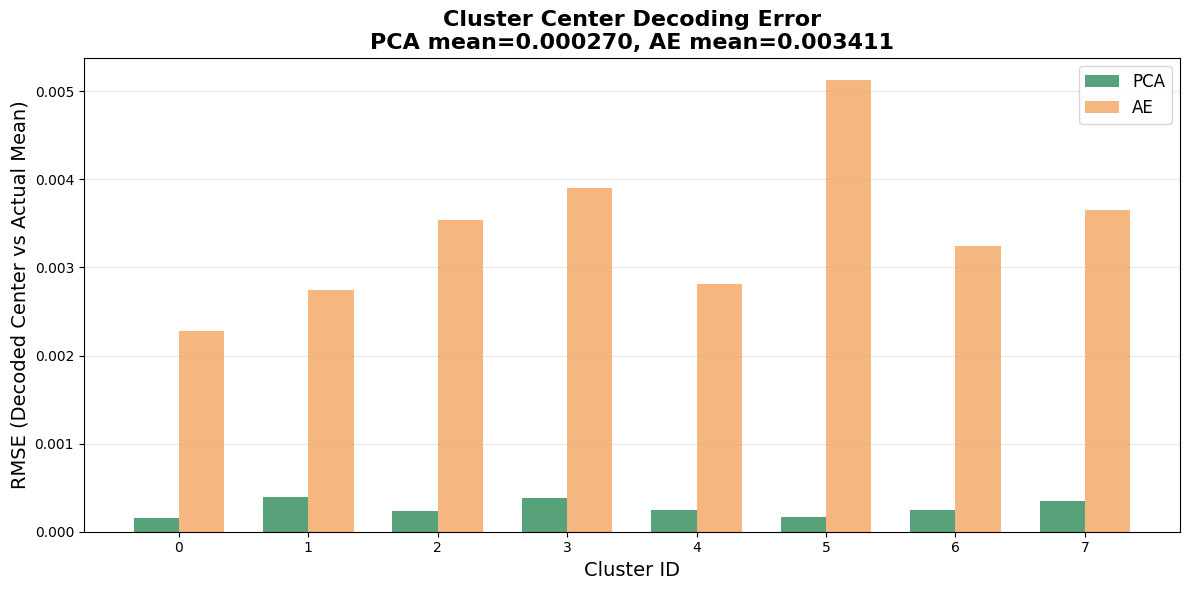

✓ Saved RMSE bar chart


In [10]:
# Bar chart: Per-cluster RMSE
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_clusters)
width = 0.35

ax.bar(x - width/2, pca_metrics_df['rmse'], width, label='PCA', color='seagreen', alpha=0.8)
ax.bar(x + width/2, ae_metrics_df['rmse'], width, label='AE', color='sandybrown', alpha=0.8)

ax.set_xlabel('Cluster ID', fontsize=14)
ax.set_ylabel('RMSE (Decoded Center vs Actual Mean)', fontsize=14)
ax.set_title(f'Cluster Center Decoding Error\nPCA mean={pca_mean_rmse:.6f}, AE mean={ae_mean_rmse:.6f}', 
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{plots_dir}/cluster_center_rmse_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved RMSE bar chart")

### Visualization: Decoded vs Actual Scatter Plots (First 2 Clusters)

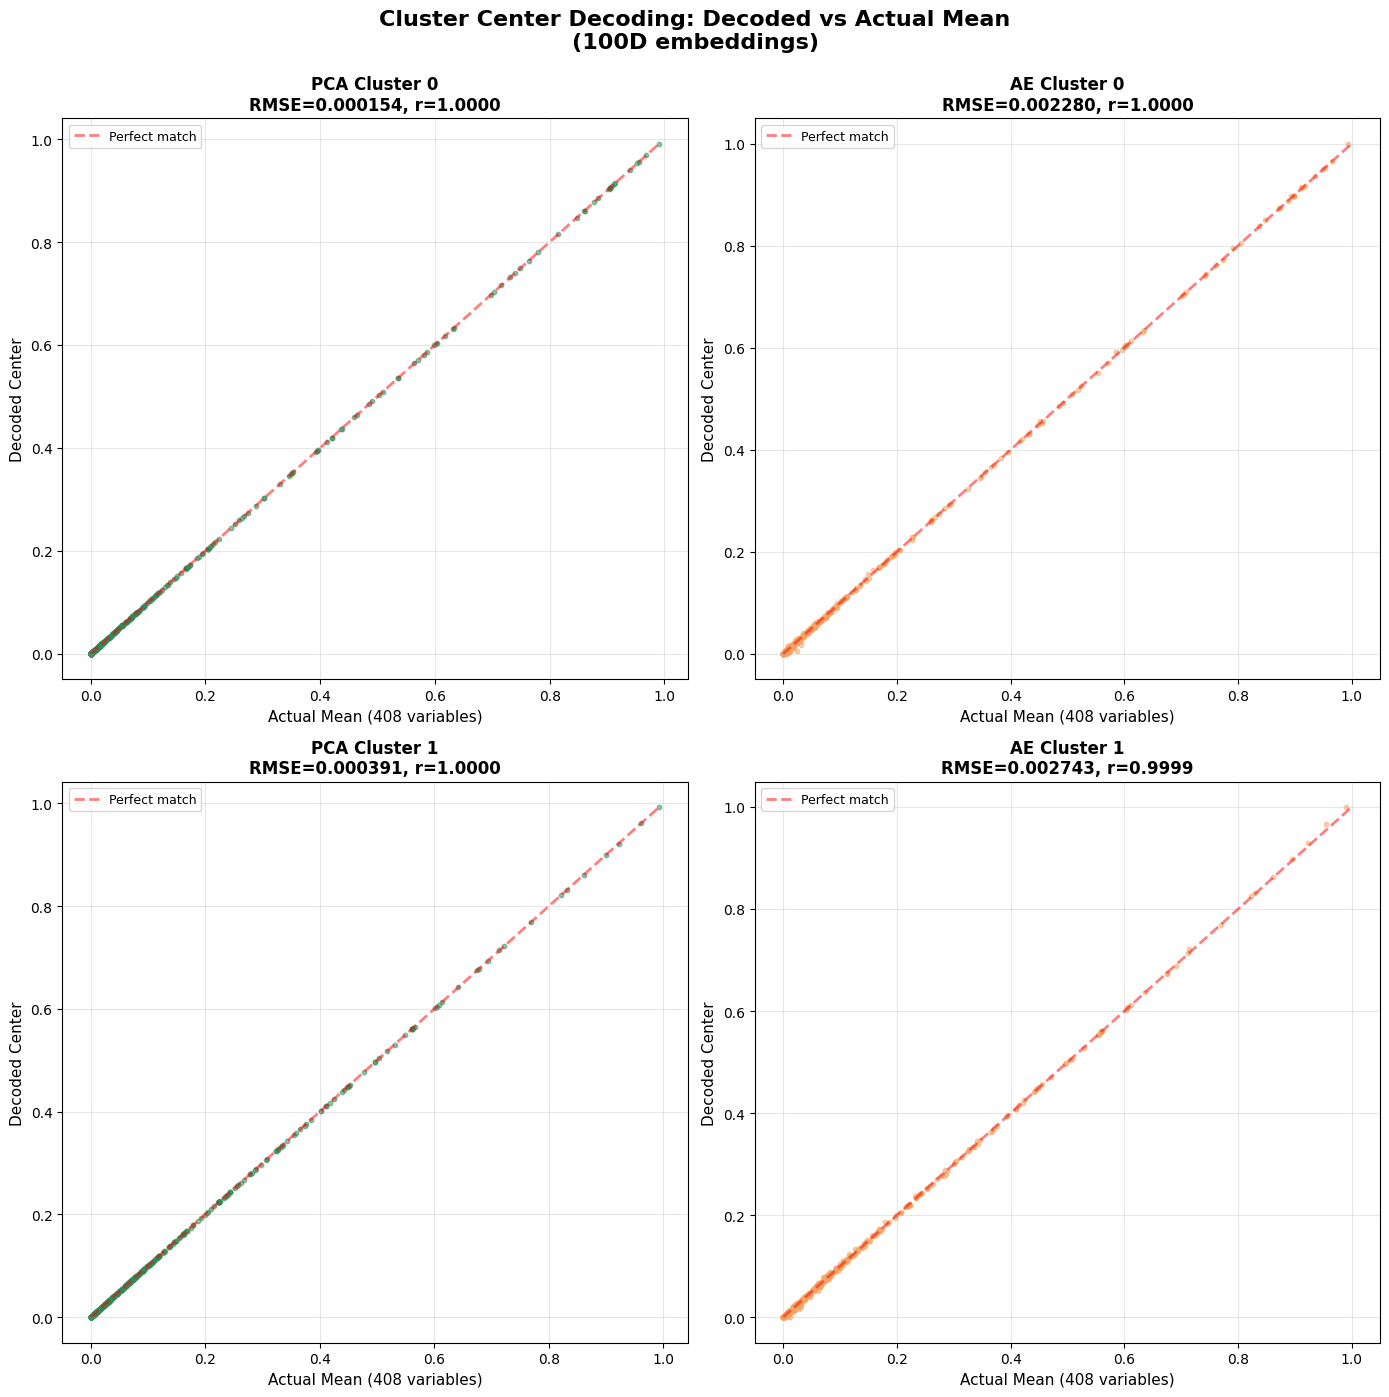

✓ Saved scatter plots


In [11]:
# Scatter plots for first 2 clusters as examples
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for cluster_idx in range(min(2, n_clusters)):
    # PCA
    ax_pca = axes[cluster_idx, 0]
    pca_decoded = pca_decoded_centers[cluster_idx]
    pca_actual = pca_actual_means[cluster_idx]
    
    ax_pca.scatter(pca_actual, pca_decoded, alpha=0.5, s=10, color='seagreen')
    lims = [min(pca_actual.min(), pca_decoded.min()), max(pca_actual.max(), pca_decoded.max())]
    ax_pca.plot(lims, lims, 'r--', alpha=0.5, linewidth=2, label='Perfect match')
    ax_pca.set_xlabel('Actual Mean (408 variables)', fontsize=11)
    ax_pca.set_ylabel('Decoded Center', fontsize=11)
    ax_pca.set_title(f'PCA Cluster {cluster_idx}\nRMSE={pca_metrics_df.iloc[cluster_idx]["rmse"]:.6f}, r={pca_metrics_df.iloc[cluster_idx]["correlation"]:.4f}',
                     fontsize=12, fontweight='bold')
    ax_pca.legend(fontsize=9)
    ax_pca.grid(True, alpha=0.3)
    
    # AE
    ax_ae = axes[cluster_idx, 1]
    ae_decoded = ae_decoded_centers[cluster_idx]
    ae_actual = ae_actual_means[cluster_idx]
    
    ax_ae.scatter(ae_actual, ae_decoded, alpha=0.5, s=10, color='sandybrown')
    lims = [min(ae_actual.min(), ae_decoded.min()), max(ae_actual.max(), ae_decoded.max())]
    ax_ae.plot(lims, lims, 'r--', alpha=0.5, linewidth=2, label='Perfect match')
    ax_ae.set_xlabel('Actual Mean (408 variables)', fontsize=11)
    ax_ae.set_ylabel('Decoded Center', fontsize=11)
    ax_ae.set_title(f'AE Cluster {cluster_idx}\nRMSE={ae_metrics_df.iloc[cluster_idx]["rmse"]:.6f}, r={ae_metrics_df.iloc[cluster_idx]["correlation"]:.4f}',
                     fontsize=12, fontweight='bold')
    ax_ae.legend(fontsize=9)
    ax_ae.grid(True, alpha=0.3)

plt.suptitle(f'Cluster Center Decoding: Decoded vs Actual Mean\n({target_dim}D embeddings)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f"{plots_dir}/cluster_center_scatter_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved scatter plots")

### Interpretation

In [12]:
print("="*80)
print("INTERPRETATION: CLUSTER CENTER DECODING")
print("="*80)

print(f"\n📊 What This Tests:")
print(f"  Does averaging in latent space produce meaningful cluster prototypes?")
print(f"  decode(cluster_center) ≈ mean(original_data_in_cluster)")

print(f"\n📈 Results:")

# PCA interpretation
if pca_mean_rmse < 0.01:
    print(f"\n✓ PCA: EXCELLENT (RMSE={pca_mean_rmse:.6f})")
    print(f"  Near-perfect match as expected due to linearity")
elif pca_mean_rmse < 0.05:
    print(f"\n✓ PCA: GOOD (RMSE={pca_mean_rmse:.6f})")
    print(f"  Small errors due to dimensionality reduction ({target_dim}D vs 408D)")
else:
    print(f"\n⚠ PCA: MODERATE (RMSE={pca_mean_rmse:.6f})")
    print(f"  Larger than expected - may need higher dimensions")

# AE interpretation
if ae_mean_rmse < 0.05:
    print(f"\n✓ AE: EXCELLENT (RMSE={ae_mean_rmse:.6f})")
    print(f"  Latent space is locally linear around cluster centers")
    print(f"  Cluster centers represent valid prototypical OAs")
elif ae_mean_rmse < 0.10:
    print(f"\n✓ AE: GOOD (RMSE={ae_mean_rmse:.6f})")
    print(f"  Acceptable non-linearity effects")
    print(f"  Cluster centers are still meaningful")
else:
    print(f"\n⚠ AE: MODERATE (RMSE={ae_mean_rmse:.6f})")
    print(f"  Non-linearity warps cluster structure significantly")
    print(f"  Cluster centers less interpretable as prototypes")

# Comparison
ratio = ae_mean_rmse / pca_mean_rmse
print(f"\n💡 AE vs PCA Comparison:")
print(f"  RMSE ratio (AE/PCA): {ratio:.2f}x")
if ratio < 2:
    print(f"  ✓ AE preserves prototype quality despite non-linearity")
    print(f"    Cluster centers in latent space are valid prototypes")
elif ratio < 5:
    print(f"  ⚠ AE has moderate prototype degradation")
    print(f"    Non-linearity affects cluster center interpretability")
else:
    print(f"  ✗ AE has significant prototype degradation")
    print(f"    Cluster centers in latent space poorly represent actual data")

print(f"\n🎯 Conclusion:")
if ratio < 2 and ae_mean_corr > 0.95:
    print(f"  The {target_dim}D latent space (both AE and PCA) produces valid cluster prototypes.")
    print(f"  Cluster centers can be decoded to interpret demographic profiles.")
else:
    print(f"  Cluster centers should be interpreted with caution.")
    print(f"  Consider using actual cluster means instead of decoded centers.")

print("\n" + "="*80)

INTERPRETATION: CLUSTER CENTER DECODING

📊 What This Tests:
  Does averaging in latent space produce meaningful cluster prototypes?
  decode(cluster_center) ≈ mean(original_data_in_cluster)

📈 Results:

✓ PCA: EXCELLENT (RMSE=0.000270)
  Near-perfect match as expected due to linearity

✓ AE: EXCELLENT (RMSE=0.003411)
  Latent space is locally linear around cluster centers
  Cluster centers represent valid prototypical OAs

💡 AE vs PCA Comparison:
  RMSE ratio (AE/PCA): 12.61x
  ✗ AE has significant prototype degradation
    Cluster centers in latent space poorly represent actual data

🎯 Conclusion:
  Cluster centers should be interpreted with caution.
  Consider using actual cluster means instead of decoded centers.



### AE-Specific Analysis: Cluster Center Decoding Quality

Focusing on AE performance in isolation, without comparison to PCA.

In [13]:
print("="*80)
print("AE CLUSTER CENTER DECODING: STANDALONE ASSESSMENT")
print("="*80)

print(f"\n📊 Context:")
print(f"  Data range: [0, 1] (normalized proportions)")
print(f"  Variables: {input_dim} census features")
print(f"  Clusters: {n_clusters}")
print(f"  Latent dimensions: {target_dim}D")

print(f"\n📈 Overall Metrics (AE):")
print(f"  Mean RMSE:        {ae_mean_rmse:.6f}")
print(f"  Mean Correlation: {ae_mean_corr:.6f}")
print(f"  RMSE Std Dev:     {ae_metrics_df['rmse'].std():.6f}")
print(f"  Corr Std Dev:     {ae_metrics_df['correlation'].std():.6f}")

print(f"\n🎯 Interpretation:")
print(f"\n  RMSE = {ae_mean_rmse:.6f}:")
if ae_mean_rmse < 0.005:
    print(f"    ✓ EXCELLENT - Average error < 0.5% on proportion data")
    print(f"    → Decoded cluster centers are highly accurate")
elif ae_mean_rmse < 0.01:
    print(f"    ✓ VERY GOOD - Average error < 1% on proportion data")
    print(f"    → Decoded cluster centers are reliable")
elif ae_mean_rmse < 0.02:
    print(f"    ○ GOOD - Average error < 2% on proportion data")
    print(f"    → Decoded cluster centers are usable with minor errors")
else:
    print(f"    ⚠ MODERATE - Average error > 2% on proportion data")
    print(f"    → Decoded cluster centers may have noticeable errors")

print(f"\n  Correlation = {ae_mean_corr:.6f}:")
if ae_mean_corr > 0.999:
    print(f"    ✓ NEAR-PERFECT - Variables maintain relative ordering")
    print(f"    → Cluster characteristics are preserved")
elif ae_mean_corr > 0.99:
    print(f"    ✓ EXCELLENT - Strong preservation of variable patterns")
elif ae_mean_corr > 0.95:
    print(f"    ○ GOOD - Reasonable preservation of structure")
else:
    print(f"    ⚠ MODERATE - Some distortion of variable patterns")

print(f"\n💡 Key Findings for AE:")
if ae_mean_rmse < 0.005 and ae_mean_corr > 0.999:
    print(f"  ✓ The {target_dim}D AE latent space preserves cluster centers with high fidelity")
    print(f"  ✓ Averaging in latent space produces valid demographic prototypes")
    print(f"  ✓ Decoded centers accurately represent cluster characteristics")
    print(f"\n  → Safe to use decoded cluster centers for interpretation")
elif ae_mean_rmse < 0.01 and ae_mean_corr > 0.99:
    print(f"  ✓ The {target_dim}D AE latent space preserves cluster structure well")
    print(f"  ✓ Minor reconstruction errors do not affect overall patterns")
    print(f"  ○ Decoded centers are suitable for cluster interpretation")
else:
    print(f"  ⚠ Some information loss when decoding cluster centers")
    print(f"  → Consider using actual cluster means for critical analysis")

print("\n" + "="*80)

AE CLUSTER CENTER DECODING: STANDALONE ASSESSMENT

📊 Context:
  Data range: [0, 1] (normalized proportions)
  Variables: 408 census features
  Clusters: 8
  Latent dimensions: 100D

📈 Overall Metrics (AE):
  Mean RMSE:        0.003411
  Mean Correlation: 0.999864
  RMSE Std Dev:     0.000876
  Corr Std Dev:     0.000088

🎯 Interpretation:

  RMSE = 0.003411:
    ✓ EXCELLENT - Average error < 0.5% on proportion data
    → Decoded cluster centers are highly accurate

  Correlation = 0.999864:
    ✓ NEAR-PERFECT - Variables maintain relative ordering
    → Cluster characteristics are preserved

💡 Key Findings for AE:
  ✓ The 100D AE latent space preserves cluster centers with high fidelity
  ✓ Averaging in latent space produces valid demographic prototypes
  ✓ Decoded centers accurately represent cluster characteristics

  → Safe to use decoded cluster centers for interpretation



### Per-Variable Analysis: Which Census Variables Are Best Preserved?

Analyzing reconstruction quality at the individual variable level.

In [14]:
print("Computing per-variable reconstruction errors...\n")

# Get variable names
var_names = df_census.columns.tolist()

# Compute per-variable RMSE across all clusters for AE
var_rmse_per_cluster = []
for cluster_id in range(n_clusters):
    ae_decoded = ae_decoded_centers[cluster_id]
    ae_actual = ae_actual_means[cluster_id]
    var_errors = np.abs(ae_decoded - ae_actual)
    var_rmse_per_cluster.append(var_errors)

# Stack and compute statistics
var_rmse_matrix = np.array(var_rmse_per_cluster)  # shape: (n_clusters, n_vars)
var_mean_error = var_rmse_matrix.mean(axis=0)     # Mean error across all clusters
var_max_error = var_rmse_matrix.max(axis=0)       # Max error across clusters
var_std_error = var_rmse_matrix.std(axis=0)       # Std dev of errors

# Create DataFrame
var_analysis = pd.DataFrame({
    'variable': var_names,
    'mean_error': var_mean_error,
    'max_error': var_max_error,
    'std_error': var_std_error,
    'mean_value': df_census.mean().values,
    'std_value': df_census.std().values
})

# Compute relative error (as percentage of mean value, handling zeros)
var_analysis['rel_error_pct'] = np.where(
    var_analysis['mean_value'] > 0.001,
    (var_analysis['mean_error'] / var_analysis['mean_value']) * 100,
    np.nan
)

# Sort by mean error
var_analysis_sorted = var_analysis.sort_values('mean_error', ascending=False)

print("="*80)
print("VARIABLE-LEVEL RECONSTRUCTION QUALITY (AE)")
print("="*80)

print(f"\n📊 Summary Statistics:")
print(f"  Variables analyzed: {len(var_names)}")
print(f"  Mean error (all vars): {var_mean_error.mean():.6f}")
print(f"  Median error: {np.median(var_mean_error):.6f}")
print(f"  90th percentile: {np.percentile(var_mean_error, 90):.6f}")
print(f"  Max error: {var_mean_error.max():.6f}")

print(f"\n🔴 Top 20 WORST reconstructed variables (highest mean error):")
print("-"*80)
for i, row in var_analysis_sorted.head(20).iterrows():
    rel_err_str = f"{row['rel_error_pct']:.1f}%" if not pd.isna(row['rel_error_pct']) else "N/A"
    print(f"  {row['variable']:20s}  Error: {row['mean_error']:.6f}  "
          f"Max: {row['max_error']:.6f}  Rel: {rel_err_str:>8s}  "
          f"Mean val: {row['mean_value']:.4f}")

print(f"\n🟢 Top 20 BEST reconstructed variables (lowest mean error):")
print("-"*80)
for i, row in var_analysis_sorted.tail(20).iterrows():
    rel_err_str = f"{row['rel_error_pct']:.1f}%" if not pd.isna(row['rel_error_pct']) else "N/A"
    print(f"  {row['variable']:20s}  Error: {row['mean_error']:.6f}  "
          f"Max: {row['max_error']:.6f}  Rel: {rel_err_str:>8s}  "
          f"Mean val: {row['mean_value']:.4f}")

# Error distribution analysis
print(f"\n📈 Error Distribution:")
n_low_error = (var_mean_error < 0.001).sum()
n_med_error = ((var_mean_error >= 0.001) & (var_mean_error < 0.005)).sum()
n_high_error = (var_mean_error >= 0.005).sum()

print(f"  Low error (<0.001):     {n_low_error:3d} variables ({n_low_error/len(var_names)*100:.1f}%)")
print(f"  Medium error (0.001-0.005): {n_med_error:3d} variables ({n_med_error/len(var_names)*100:.1f}%)")
print(f"  High error (>0.005):    {n_high_error:3d} variables ({n_high_error/len(var_names)*100:.1f}%)")

# Save detailed results
var_analysis_sorted.to_csv(f"{results_dir}/ae_variable_reconstruction_errors_{target_dim}d.csv", index=False)
print(f"\n✓ Saved detailed per-variable analysis to {results_dir}/ae_variable_reconstruction_errors_{target_dim}d.csv")

print("\n" + "="*80)

Computing per-variable reconstruction errors...

VARIABLE-LEVEL RECONSTRUCTION QUALITY (AE)

📊 Summary Statistics:
  Variables analyzed: 408
  Mean error (all vars): 0.002005
  Median error: 0.001503
  90th percentile: 0.004072
  Max error: 0.024464

🔴 Top 20 WORST reconstructed variables (highest mean error):
--------------------------------------------------------------------------------
  ts0270005             Error: 0.024464  Max: 0.049894  Rel:    73.1%  Mean val: 0.0334
  ts0010002             Error: 0.013100  Max: 0.030894  Rel:     1.3%  Mean val: 0.9885
  ts0010003             Error: 0.012990  Max: 0.030721  Rel:   112.6%  Mean val: 0.0115
  ts0270003             Error: 0.008989  Max: 0.017739  Rel:     5.9%  Mean val: 0.1536
  ts0270004             Error: 0.007722  Max: 0.015276  Rel:     5.6%  Mean val: 0.1378
  ts0560002             Error: 0.007533  Max: 0.025757  Rel:     0.8%  Mean val: 0.9501
  ts0390002             Error: 0.007326  Max: 0.010605  Rel:     0.8%  Mean val

### Visualizations: Per-Variable Error Distributions

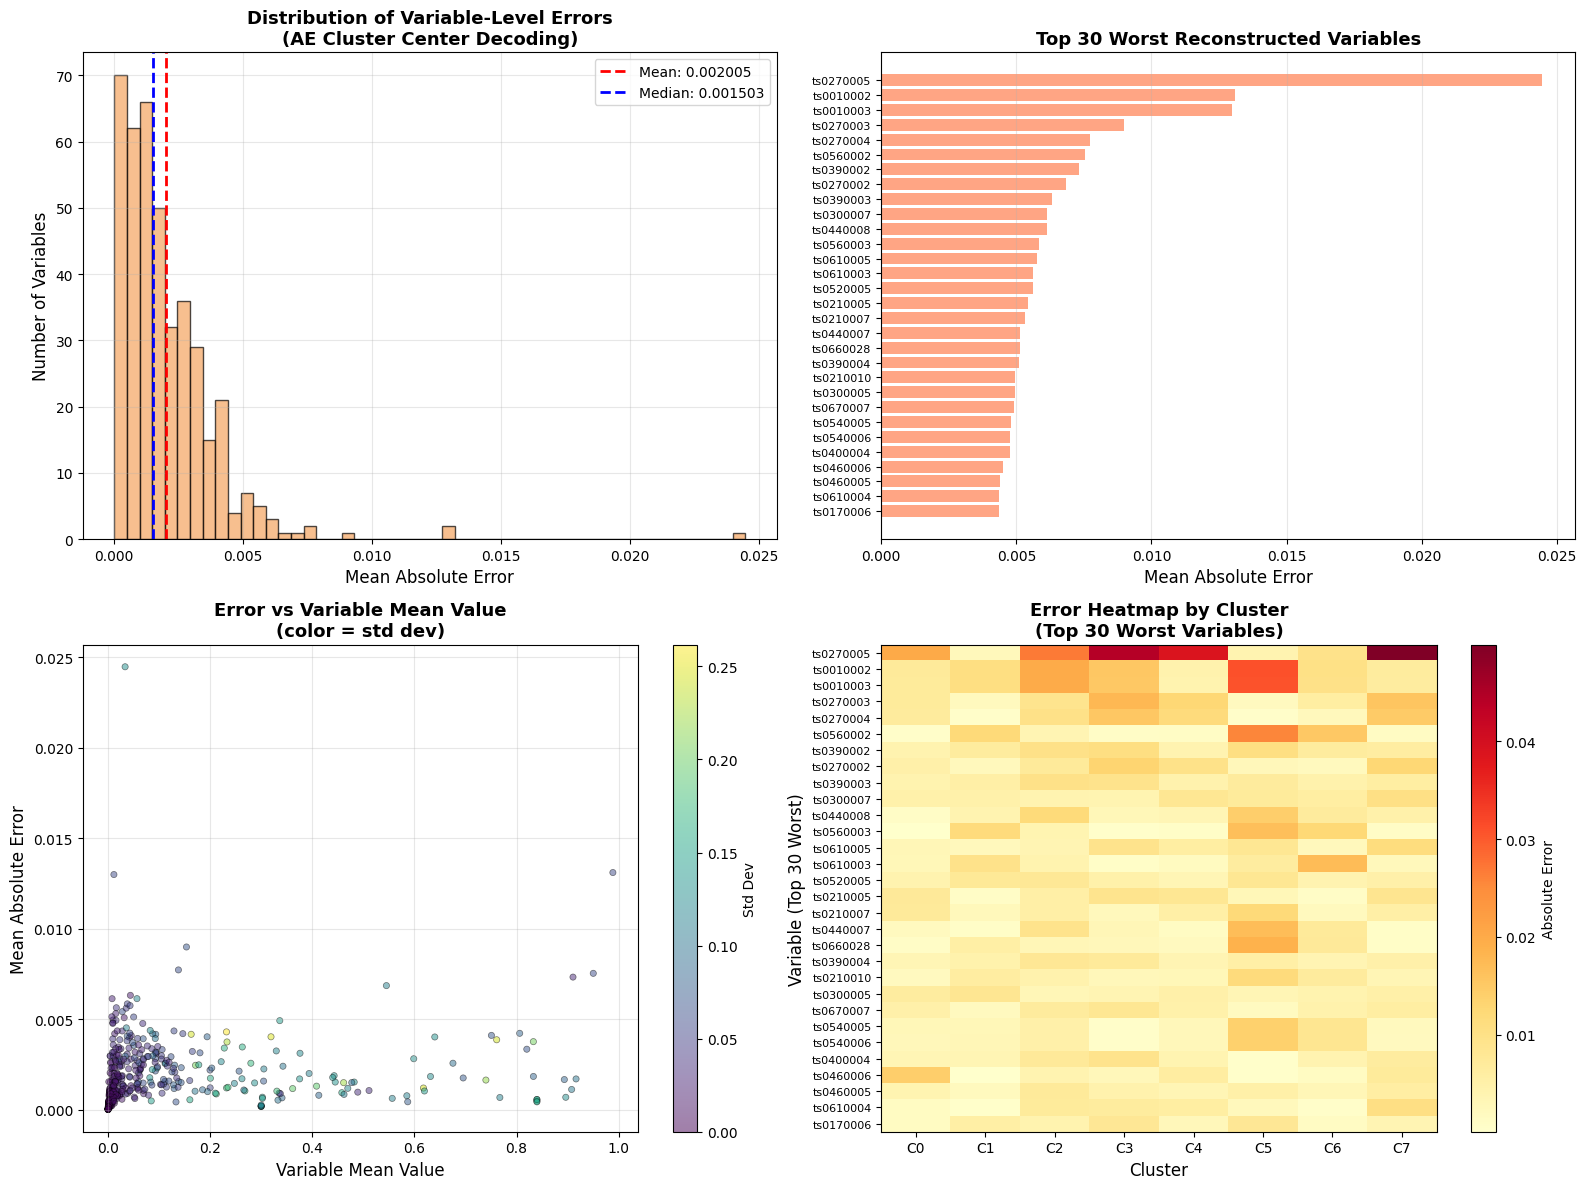

✓ Saved variable error visualization to ./plots/clustering_plots//ae_variable_error_analysis_100d.png


In [15]:
# Create comprehensive visualization of per-variable errors
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram of mean errors
ax1 = axes[0, 0]
ax1.hist(var_mean_error, bins=50, color='sandybrown', alpha=0.7, edgecolor='black')
ax1.axvline(var_mean_error.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {var_mean_error.mean():.6f}')
ax1.axvline(np.median(var_mean_error), color='blue', linestyle='--', linewidth=2,
            label=f'Median: {np.median(var_mean_error):.6f}')
ax1.set_xlabel('Mean Absolute Error', fontsize=12)
ax1.set_ylabel('Number of Variables', fontsize=12)
ax1.set_title('Distribution of Variable-Level Errors\n(AE Cluster Center Decoding)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Top 30 worst variables
ax2 = axes[0, 1]
top_worst = var_analysis_sorted.head(30)
y_pos = np.arange(len(top_worst))
ax2.barh(y_pos, top_worst['mean_error'].values, color='coral', alpha=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_worst['variable'].values, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('Mean Absolute Error', fontsize=12)
ax2.set_title('Top 30 Worst Reconstructed Variables', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# 3. Error vs Mean Value scatter
ax3 = axes[1, 0]
scatter = ax3.scatter(var_analysis['mean_value'], var_analysis['mean_error'], 
                     alpha=0.5, s=20, c=var_analysis['std_value'], 
                     cmap='viridis', edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Variable Mean Value', fontsize=12)
ax3.set_ylabel('Mean Absolute Error', fontsize=12)
ax3.set_title('Error vs Variable Mean Value\n(color = std dev)', 
              fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Std Dev', fontsize=10)

# 4. Heatmap of errors across clusters (top 30 worst vars)
ax4 = axes[1, 1]
worst_var_indices = var_analysis_sorted.head(30).index
heatmap_data = var_rmse_matrix[:, worst_var_indices].T
im = ax4.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax4.set_yticks(np.arange(30))
ax4.set_yticklabels([var_names[i][:20] for i in worst_var_indices], fontsize=8)
ax4.set_xticks(np.arange(n_clusters))
ax4.set_xticklabels([f'C{i}' for i in range(n_clusters)])
ax4.set_xlabel('Cluster', fontsize=12)
ax4.set_ylabel('Variable (Top 30 Worst)', fontsize=12)
ax4.set_title('Error Heatmap by Cluster\n(Top 30 Worst Variables)', 
              fontsize=13, fontweight='bold')
cbar2 = plt.colorbar(im, ax=ax4)
cbar2.set_label('Absolute Error', fontsize=10)

plt.tight_layout()
plt.savefig(f"{plots_dir}/ae_variable_error_analysis_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved variable error visualization to {plots_dir}/ae_variable_error_analysis_{target_dim}d.png")

In [16]:
print("="*80)
print(f"CLUSTER CENTER DECODING SUMMARY ({target_dim}D, {n_clusters} clusters, 500 EPOCHS)")
print("="*80)

print("\n1. CLUSTER CENTER DECODING METRICS:")
print("-"*80)
print(comparison_df.to_string(index=False))

print(f"\n2. OVERALL DECODING QUALITY:")
print("-"*80)
print(f"  PCA Mean RMSE:        {pca_mean_rmse:.6f}")
print(f"  PCA Mean Correlation: {pca_mean_corr:.6f}")
print(f"  AE Mean RMSE:         {ae_mean_rmse:.6f}")
print(f"  AE Mean Correlation:  {ae_mean_corr:.6f}")
print(f"  RMSE ratio (AE/PCA):  {ae_mean_rmse / pca_mean_rmse:.2f}x")

print(f"\n3. CLUSTER SIZES:")
print("-"*80)
pca_sizes = [np.sum(pca_clusters == i) for i in range(n_clusters)]
ae_sizes = [np.sum(ae_clusters == i) for i in range(n_clusters)]
size_comparison = pd.DataFrame({
    'Cluster': range(n_clusters),
    'PCA': pca_sizes,
    'AE': ae_sizes
})
print(size_comparison.to_string(index=False))

print("\n" + "="*80)
print(f"Plots saved to: {plots_dir}")
print(f"Data saved to: {results_dir}")
print("="*80)

print("\nKey Findings:")
if ae_mean_rmse < 0.005:
    print(f"- AE decoding quality: EXCELLENT (Mean RMSE={ae_mean_rmse:.6f})")
elif ae_mean_rmse < 0.01:
    print(f"- AE decoding quality: VERY GOOD (Mean RMSE={ae_mean_rmse:.6f})")
else:
    print(f"- AE decoding quality: GOOD (Mean RMSE={ae_mean_rmse:.6f})")

if ae_mean_corr > 0.999:
    print(f"- Cluster center correlation: NEAR-PERFECT ({ae_mean_corr:.6f})")
    print("  -> Decoded cluster centers faithfully represent demographic profiles")
else:
    print(f"- Cluster center correlation: {ae_mean_corr:.6f}")

CLUSTER CENTER DECODING SUMMARY (100D, 8 clusters, 500 EPOCHS)

1. CLUSTER CENTER DECODING METRICS:
--------------------------------------------------------------------------------
 Cluster  PCA_RMSE  AE_RMSE  PCA_Corr  AE_Corr
       0  0.000154 0.002280  1.000000 0.999954
       1  0.000391 0.002743  0.999998 0.999901
       2  0.000230 0.003538  0.999999 0.999864
       3  0.000379 0.003897  0.999998 0.999858
       4  0.000245 0.002810  0.999999 0.999926
       5  0.000162 0.005128  1.000000 0.999664
       6  0.000249 0.003240  0.999999 0.999888
       7  0.000353 0.003651  0.999998 0.999858

2. OVERALL DECODING QUALITY:
--------------------------------------------------------------------------------
  PCA Mean RMSE:        0.000270
  PCA Mean Correlation: 0.999999
  AE Mean RMSE:         0.003411
  AE Mean Correlation:  0.999864
  RMSE ratio (AE/PCA):  12.61x

3. CLUSTER SIZES:
--------------------------------------------------------------------------------
 Cluster   PCA    AE
 